# Credit Card Fraud Detection

## Overview
This notebook demonstrates machine learning techniques for detecting credit card fraud using various classification algorithms. The dataset contains transactions made by credit cards in September 2013 by European cardholders.

## Dataset Information
- **Features**: 30 numerical features (V1-V28) + Time and Amount
- **Target**: Class (0 = Normal, 1 = Fraud)
- **Size**: 284,807 transactions
- **Fraud Rate**: ~0.172% (highly imbalanced dataset)

## Objectives
1. Explore and analyze the dataset
2. Preprocess the data for machine learning
3. Train and compare different classification models
4. Evaluate model performance using appropriate metrics
5. Optimize model performance through threshold tuning


## 1. Environment Setup and Dependencies


In [28]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Machine learning libraries
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

Libraries imported successfully!


## 2. Data Loading and Initial Exploration


In [29]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Overview


In [30]:
# Create a copy for analysis
df_copy = df.copy()

# Display dataset information
print("Dataset Info:")
print(f"Shape: {df_copy.shape}")
print(f"Columns: {list(df_copy.columns)}")
print(f"Data types:\n{df_copy.dtypes.value_counts()}")

# Show first few rows
df_copy.head()

Dataset Info:
Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Data types:
float64    30
int64       1
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Statistical Summary


In [31]:
# Statistical summary of the dataset
print("Statistical Summary:")
print("=" * 50)
df_copy.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### Missing Values Check


In [32]:
# Check for missing values
missing_values = df_copy.isnull().sum()
print("Missing Values Analysis:")
print("=" * 30)
print(missing_values)


Missing Values Analysis:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### Target Variable Analysis


In [33]:
# Extract target variable
target = df_copy.pop('Class')

# Analyze target variable distribution
print("Target Variable Analysis:")
print("=" * 30)
print(f"Class distribution:")
print(target.value_counts())
print(f"\nClass percentages:")
print(target.value_counts(normalize=True) * 100)

# Check for fraud cases
fraud_cases = target[target == 1]
print(f"\nNumber of fraud cases: {len(fraud_cases)}")
print(f"Fraud rate: {len(fraud_cases) / len(target) * 100:.2f}%")

Target Variable Analysis:
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Number of fraud cases: 492
Fraud rate: 0.17%


## 3. Data Preprocessing


In [34]:
# Prepare features for modeling
data = df_copy.copy()

print("Features for modeling:")
print(f"Data shape: {data.shape}")

Features for modeling:
Data shape: (284807, 30)


### Feature Selection


In [35]:
# Remove Time column as it's not useful for fraud detection
# Time represents seconds elapsed between each transaction and the first transaction
data = data.drop(columns=['Time'])


### Data Scaling


In [36]:
target.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [37]:
# Initialize StandardScaler for feature normalization
scaler = StandardScaler()



In [38]:
# Fit and transform the data
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

print("Data scaling completed!")
print(f"Scaled data shape: {data_scaled.shape}")
print("\nScaled data statistics:")
print(data_scaled.describe().T[['mean', 'std']].round(3))

Data scaling completed!
Scaled data shape: (284807, 29)

Scaled data statistics:
        mean  std
V1      -0.0  1.0
V2      -0.0  1.0
V3      -0.0  1.0
V4      -0.0  1.0
V5       0.0  1.0
V6       0.0  1.0
V7       0.0  1.0
V8      -0.0  1.0
V9       0.0  1.0
V10      0.0  1.0
V11     -0.0  1.0
V12      0.0  1.0
V13     -0.0  1.0
V14      0.0  1.0
V15     -0.0  1.0
V16      0.0  1.0
V17      0.0  1.0
V18      0.0  1.0
V19      0.0  1.0
V20     -0.0  1.0
V21     -0.0  1.0
V22      0.0  1.0
V23      0.0  1.0
V24      0.0  1.0
V25     -0.0  1.0
V26      0.0  1.0
V27      0.0  1.0
V28     -0.0  1.0
Amount   0.0  1.0


### Train-Test Split


In [39]:
# Split the data into training and testing sets
# Using stratify to maintain the same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, target, 
    test_size=0.2, 
    stratify=target,
    random_state=42
)

print("Train-Test Split Results:")
print("=" * 30)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training set fraud rate: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Test set fraud rate: {y_test.sum() / len(y_test) * 100:.2f}%")

Train-Test Split Results:
Training set size: 227845 samples
Test set size: 56962 samples
Training set fraud rate: 0.17%
Test set fraud rate: 0.17%


## 4. Model Training and Evaluation


### Model 1: Perceptron


In [40]:
# Initialize and train Perceptron
perceptron = Perceptron(eta0=0.2, random_state=42)
perceptron.fit(X_train, y_train)

print("Perceptron model trained successfully!")
print(f"Number of iterations: {perceptron.n_iter_}")
print(f"Training accuracy: {perceptron.score(X_train, y_train):.4f}")

Perceptron model trained successfully!
Number of iterations: 6
Training accuracy: 0.9992


In [41]:
# Evaluate Perceptron on test set
test_accuracy = perceptron.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Make predictions
y_pred = perceptron.predict(X_test)

# Calculate additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nPerceptron Performance Metrics:")
print("=" * 35)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

Test Accuracy: 0.9991

Perceptron Performance Metrics:
Precision: 0.7396
Recall: 0.7245
F1-score: 0.7320

Confusion Matrix:
[[56839    25]
 [   27    71]]


In [42]:
# Analyze misclassified samples
misclassified = X_test[(perceptron.predict(X_test) != y_test)]
print(f"Number of misclassified samples: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified) / len(X_test) * 100:.2f}%")

# Show some misclassified examples
if len(misclassified) > 0:
    print("\nFirst 5 misclassified samples:")
    print(misclassified.head())

Number of misclassified samples: 52
Misclassification rate: 0.09%

First 5 misclassified samples:
              V1        V2         V3        V4         V5        V6  \
190263 -0.649473  1.106770  -2.513177  0.412298  -0.464586 -1.042615   
102442 -6.735448  7.742946  -6.533642  2.345092  -3.478497  4.323496   
63551  -1.550219 -1.204092   2.787207  3.179019  10.365476 -6.990191   
14920  -9.164599  6.702011 -13.680216  4.291035  -9.701011 -3.402383   
153457 -1.603680  1.219734  -0.402578  4.200015  -1.353770  0.568006   

               V7         V8        V9       V10  ...       V20        V21  \
190263  -1.579555   0.982894 -1.868865 -3.072111  ... -0.035371   1.169464   
102442 -15.157238 -31.275101 -0.356389 -4.640228  ... -4.530993  37.034714   
63551  -13.246512  -0.093973  0.582365  3.207261  ... -1.497880   0.915638   
14920  -12.277303  10.131916 -3.665364 -8.281610  ...  2.221892   2.446669   
153457  -2.678737   0.190880 -0.853694 -0.896812  ... -0.730714   1.917587   



### Model 2: Multi-Layer Perceptron (MLP)


In [43]:
# Initialize and train MLP Classifier
mlp = MLPClassifier(
    solver='lbfgs', 
    alpha=1e-5,
    hidden_layer_sizes=(5, 3, 2),
    random_state=42,
    max_iter=1000
)

print("Training MLP Classifier...")
mlp.fit(X_train, y_train)

print("MLP Classifier trained successfully!")
print(f"Number of iterations: {mlp.n_iter_}")
print(f"Training accuracy: {mlp.score(X_train, y_train):.4f}")


Training MLP Classifier...
MLP Classifier trained successfully!
Number of iterations: 127
Training accuracy: 0.9994


In [44]:
# Evaluate MLP Classifier on test set
test_accuracy_mlp = mlp.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy_mlp:.4f}")

# Make predictions
y_pred_mlp = mlp.predict(X_test)

# Calculate metrics
precision_mlp = precision_score(y_test, y_pred_mlp)
recall_mlp = recall_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp)

print("\nMLP Classifier Performance Metrics:")
print("=" * 40)
print(f"Precision: {precision_mlp:.4f}")
print(f"Recall: {recall_mlp:.4f}")
print(f"F1-score: {f1_mlp:.4f}")

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print(f"\nConfusion Matrix:")
print(cm_mlp)

Test Accuracy: 0.9994

MLP Classifier Performance Metrics:
Precision: 0.7961
Recall: 0.8367
F1-score: 0.8159

Confusion Matrix:
[[56843    21]
 [   16    82]]


### Model 3: Logistic Regression


In [45]:
# Initialize and train Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', random_state=42)

print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Logistic Regression trained successfully!")
print(f"Training accuracy: {log_reg.score(X_train, y_train):.4f}")

# Evaluate on test set
test_accuracy_lr = log_reg.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy_lr:.4f}")

# Make predictions
y_pred_lr = log_reg.predict(X_test)

# Calculate metrics
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("\nLogistic Regression Performance Metrics:")
print("=" * 45)
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-score: {f1_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:")
print(cm_lr)

Training Logistic Regression...
Logistic Regression trained successfully!
Training accuracy: 0.9756
Test Accuracy: 0.9745

Logistic Regression Performance Metrics:
Precision: 0.0586
Recall: 0.9184
F1-score: 0.1101

Confusion Matrix:
[[55417  1447]
 [    8    90]]


## 5. Threshold Tuning and Model Comparison


### Threshold Tuning for MLP Classifier


In [46]:
# Get predicted probabilities for MLP
y_proba_mlp = mlp.predict_proba(X_test)[:, 1]

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.1)
print("Threshold Tuning Results:")
print("=" * 30)

for threshold in thresholds:
    y_pred_thresh = (y_proba_mlp >= threshold).astype(int)
    precision_thresh = precision_score(y_test, y_pred_thresh)
    recall_thresh = recall_score(y_test, y_pred_thresh)
    f1_thresh = f1_score(y_test, y_pred_thresh)
    
    print(f"Threshold: {threshold:.1f} | Precision: {precision_thresh:.3f} | Recall: {recall_thresh:.3f} | F1: {f1_thresh:.3f}")

# Find optimal threshold (highest F1-score)
best_f1 = 0
best_threshold = 0.5

for threshold in np.arange(0.01, 0.99, 0.01):
    y_pred_thresh = (y_proba_mlp >= threshold).astype(int)
    f1_thresh = f1_score(y_test, y_pred_thresh)
    
    if f1_thresh > best_f1:
        best_f1 = f1_thresh
        best_threshold = threshold

print(f"\nOptimal threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.3f}")

# Apply optimal threshold
y_pred_optimal = (y_proba_mlp >= best_threshold).astype(int)
precision_optimal = precision_score(y_test, y_pred_optimal)
recall_optimal = recall_score(y_test, y_pred_optimal)

print(f"\nOptimal Threshold Results:")
print(f"Precision: {precision_optimal:.3f}")
print(f"Recall: {recall_optimal:.3f}")
print(f"F1-score: {best_f1:.3f}")


Threshold Tuning Results:
Threshold: 0.1 | Precision: 0.680 | Recall: 0.847 | F1: 0.755
Threshold: 0.2 | Precision: 0.689 | Recall: 0.837 | F1: 0.756
Threshold: 0.3 | Precision: 0.707 | Recall: 0.837 | F1: 0.766
Threshold: 0.4 | Precision: 0.752 | Recall: 0.837 | F1: 0.792
Threshold: 0.5 | Precision: 0.796 | Recall: 0.837 | F1: 0.816
Threshold: 0.6 | Precision: 0.812 | Recall: 0.837 | F1: 0.824
Threshold: 0.7 | Precision: 0.816 | Recall: 0.816 | F1: 0.816
Threshold: 0.8 | Precision: 0.840 | Recall: 0.806 | F1: 0.823

Optimal threshold: 0.52
Best F1-score: 0.824

Optimal Threshold Results:
Precision: 0.812
Recall: 0.837
F1-score: 0.824


### Model Comparison


In [47]:
# Create comparison table
models_comparison = pd.DataFrame({
    'Model': ['Perceptron', 'MLP Classifier', 'Logistic Regression'],
    'Accuracy': [test_accuracy, test_accuracy_mlp, test_accuracy_lr],
    'Precision': [precision, precision_mlp, precision_lr],
    'Recall': [recall, recall_mlp, recall_lr],
    'F1-Score': [f1, f1_mlp, f1_lr]
})

print("Model Performance Comparison:")
print("=" * 50)
print(models_comparison.round(4))

# Find best model based on F1-score
best_model_idx = models_comparison['F1-Score'].idxmax()
best_model = models_comparison.loc[best_model_idx, 'Model']
best_f1_score = models_comparison.loc[best_model_idx, 'F1-Score']

print(f"\nBest performing model: {best_model}")
print(f"Best F1-score: {best_f1_score:.4f}")

Model Performance Comparison:
                 Model  Accuracy  Precision  Recall  F1-Score
0           Perceptron    0.9991     0.7396  0.7245    0.7320
1       MLP Classifier    0.9994     0.7961  0.8367    0.8159
2  Logistic Regression    0.9745     0.0586  0.9184    0.1101

Best performing model: MLP Classifier
Best F1-score: 0.8159


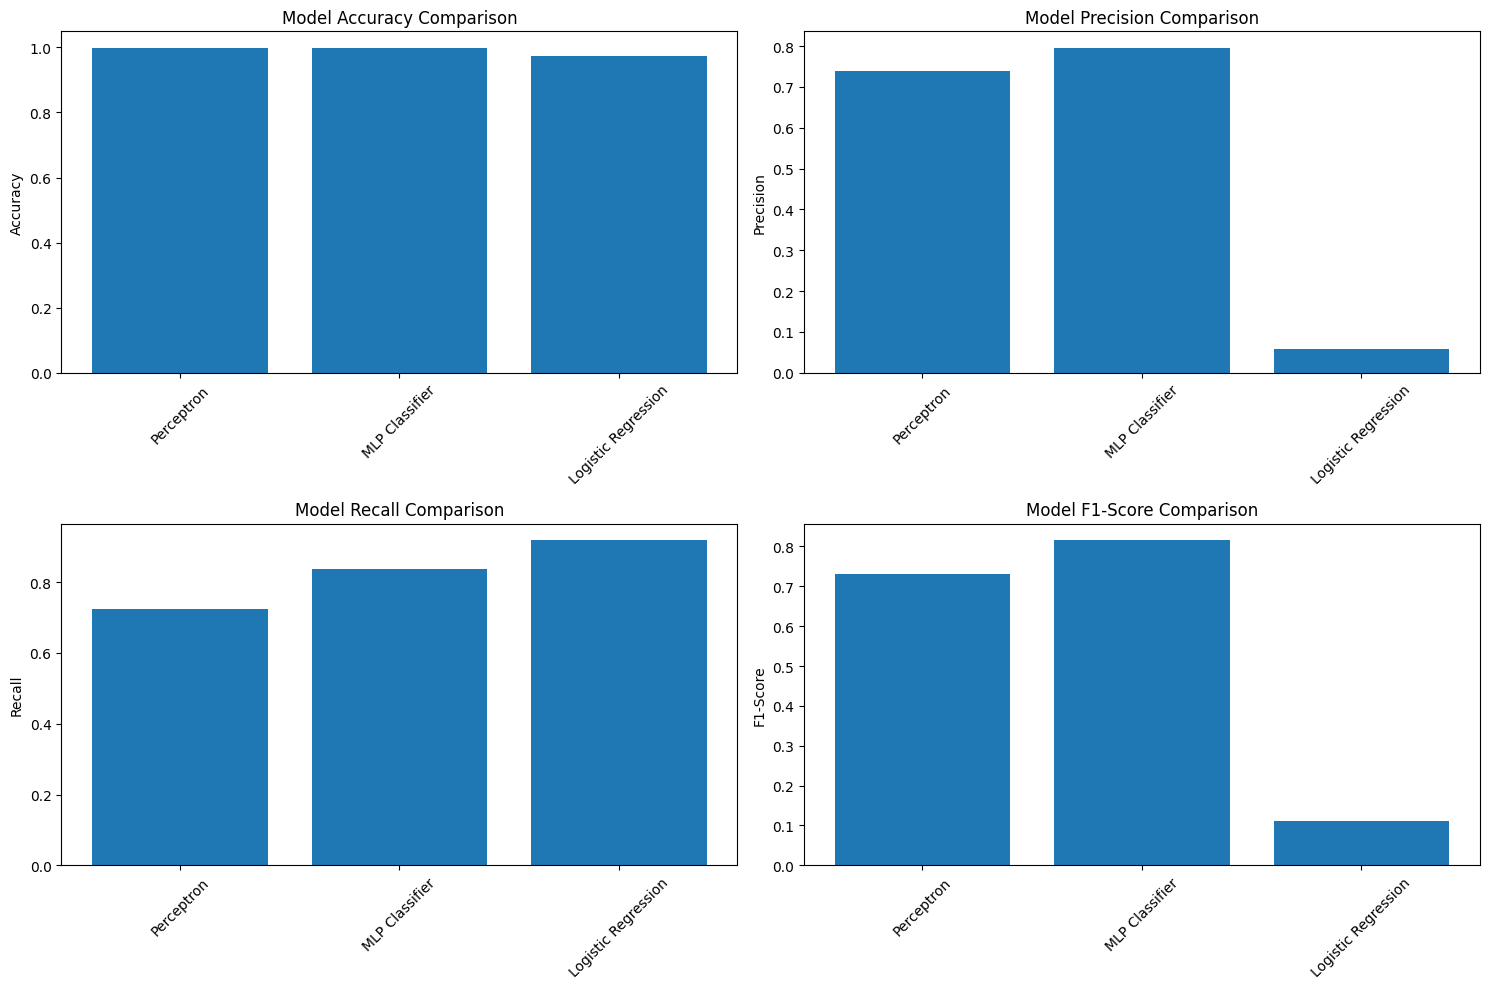

In [48]:
# Visualization of model performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0, 0].bar(models_comparison['Model'], models_comparison['Accuracy'])
axes[0, 0].set_title('Model Accuracy Comparison')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Precision comparison
axes[0, 1].bar(models_comparison['Model'], models_comparison['Precision'])
axes[0, 1].set_title('Model Precision Comparison')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].tick_params(axis='x', rotation=45)

# Recall comparison
axes[1, 0].bar(models_comparison['Model'], models_comparison['Recall'])
axes[1, 0].set_title('Model Recall Comparison')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].tick_params(axis='x', rotation=45)

# F1-Score comparison
axes[1, 1].bar(models_comparison['Model'], models_comparison['F1-Score'])
axes[1, 1].set_title('Model F1-Score Comparison')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

